> **Chapter 13, Part 1** | Continues from [13.0 Why Governance Needs a Fractal Lens](13.0%20Why%20Governance%20Needs%20a%20Fractal%20Lens.ipynb). **Focus:** types and a concrete decomposition.

# The Multi-Scale Pressure Field

Institutional theory names three pressure mechanisms (DiMaggio and Powell, 1983).

- **Coercive** pressure comes from regulation, contractual mandate, and explicit power asymmetry. DORA, the EU AI Act, BCBS 239, SOC 2 audits, and client master service agreements are all coercive sources.
- **Mimetic** pressure comes from imitation under uncertainty. Firms copy peers when no clearly correct answer exists. Adopting a competitor's data fabric architecture because they did is mimetic.
- **Normative** pressure comes from professional standards and shared training. CDMP certifications, professional ethics codes, and university curricula transmit normative pressure.

The mechanisms are usually treated qualitatively. This notebook treats them quantitatively, by introducing a `PressureVector` type that lives at one scale and a `decompose_across_scales` operation that produces a 3xN matrix of intensities. The math is light. The discipline is in the labeling.

## Why scales matter

Institutional pressures look different at different scales. A regulation operates strongly at the firm scale (the firm is the legal entity bound by the regulation) but weakly at the practitioner scale (the practitioner is bound by their professional code, not directly by DORA). A peer mimetic pressure operates strongly at the firm-and-division scale (where benchmarking happens) but weakly at the field and practitioner scales. A normative pressure from a professional code operates strongly at the practitioner scale and weakly at the field scale.

If we measure pressure at only one scale, we collapse this multi-scale structure into a single number and lose the diagnostic that institutional theory was designed to deliver. The fractal-graph apparatus from Chapter 12 generalizes naturally: a pressure field is a multi-scale object whose structure is more interesting than any single-scale summary.


In [1]:
from dataclasses import dataclass, field
from enum import Enum
from typing import List
import numpy as np
import matplotlib.pyplot as plt


class Scale(str, Enum):
    FIELD = 'field'
    FIRM = 'firm'
    DIVISION = 'division'
    TEAM = 'team'
    PRACTITIONER = 'practitioner'


SCALE_ORDER = [Scale.FIELD, Scale.FIRM, Scale.DIVISION, Scale.TEAM, Scale.PRACTITIONER]


@dataclass
class PressureVector:
    coercive: float
    mimetic: float
    normative: float
    scale: Scale
    evidence: List[str] = field(default_factory=list)

    def __post_init__(self) -> None:
        # V003: pressures clipped to [0, 1].
        self.coercive = float(np.clip(self.coercive, 0.0, 1.0))
        self.mimetic = float(np.clip(self.mimetic, 0.0, 1.0))
        self.normative = float(np.clip(self.normative, 0.0, 1.0))

    def as_array(self) -> np.ndarray:
        return np.array([self.coercive, self.mimetic, self.normative])

    def l1(self) -> float:
        return float(self.coercive + self.mimetic + self.normative)

    def dominant(self) -> str:
        names = ['coercive', 'mimetic', 'normative']
        return names[int(np.argmax(self.as_array()))]


# Self-check.
example = PressureVector(coercive=1.4, mimetic=0.3, normative=-0.1, scale=Scale.FIRM,
                         evidence=['MSA fairness clause', 'competitor benchmark study'])
assert example.coercive == 1.0, 'V003 clipping failed (upper)'
assert example.normative == 0.0, 'V003 clipping failed (lower)'
print(f'PressureVector at {example.scale.value}: {example.as_array()} (dominant={example.dominant()}, L1={example.l1():.2f})')


PressureVector at firm: [1.  0.3 0. ] (dominant=coercive, L1=1.30)


## A worked example

The example here is a financial-services consulting firm subject to all three pressure mechanisms simultaneously: coercive pressure from regulation (DORA, EU AI Act, BCBS 239), mimetic pressure from peer firms (consulting industry benchmarks), and normative pressure from professional bodies (DAMA, ISACA, CDMP credentials). Walsh et al. (2025) and Volz et al. (2025) document exactly this kind of layered pressure environment for knowledge-intensive firms.

The intensities below are illustrative; in research use, they would be derived from the dissertation's hand-coded interview transcripts or from a validated parser (see notebook 13.5). Here, they make the apparatus concrete enough to manipulate.


In [2]:
def decompose_across_scales(case_name: str, decomposition: dict) -> List[PressureVector]:
    """Materialize a pressure field as a list of PressureVectors, one per scale.

    `decomposition` is a dict keyed by Scale where each value is a dict with
    keys 'coercive', 'mimetic', 'normative', and optional 'evidence'.
    """
    out = []
    for scale in SCALE_ORDER:
        d = decomposition.get(scale, {})
        out.append(PressureVector(
            coercive=d.get('coercive', 0.0),
            mimetic=d.get('mimetic', 0.0),
            normative=d.get('normative', 0.0),
            scale=scale,
            evidence=d.get('evidence', []),
        ))
    return out


# Decomposition for a financial-services consulting firm.
FS_FIRM = decompose_across_scales(
    'Financial-services consulting firm: data and AI governance',
    decomposition={
        Scale.FIELD:        {'coercive': 0.95, 'mimetic': 0.30, 'normative': 0.45,
                             'evidence': ['DORA Article 9', 'EU AI Act Article 10', 'BCBS 239']},
        Scale.FIRM:         {'coercive': 0.40, 'mimetic': 0.70, 'normative': 0.55,
                             'evidence': ['Big-3 data-fabric benchmarking', 'firm-level ISO 42001 program']},
        Scale.DIVISION:     {'coercive': 0.55, 'mimetic': 0.65, 'normative': 0.60,
                             'evidence': ['MSA-imposed audit logs', 'sister-division platform mimicry']},
        Scale.TEAM:         {'coercive': 0.30, 'mimetic': 0.55, 'normative': 0.75,
                             'evidence': ['internal SOPs', 'peer code review norms']},
        Scale.PRACTITIONER: {'coercive': 0.20, 'mimetic': 0.35, 'normative': 0.85,
                             'evidence': ['CDMP certification', 'tacit professional ethic']},
    },
)
matrix = np.stack([v.as_array() for v in FS_FIRM], axis=1)
print('Decomposed pressure matrix (3 mechanisms x 5 scales):')
print(np.round(matrix, 2))


Decomposed pressure matrix (3 mechanisms x 5 scales):
[[0.95 0.4  0.55 0.3  0.2 ]
 [0.3  0.7  0.65 0.55 0.35]
 [0.45 0.55 0.6  0.75 0.85]]


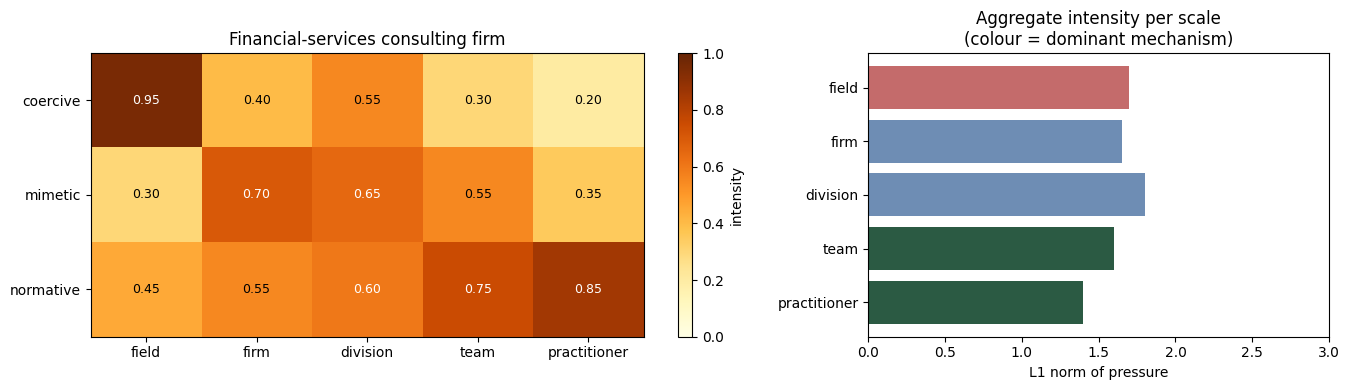

In [3]:
def render_pressure_field(field_, title='Pressure field across scales'):
    matrix = np.stack([v.as_array() for v in field_], axis=1)
    scales = [v.scale.value for v in field_]
    mechanisms = ['coercive', 'mimetic', 'normative']

    fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.0), gridspec_kw={'width_ratios': [1.5, 1]})

    ax = axes[0]
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrBr', vmin=0, vmax=1)
    ax.set_xticks(range(len(scales)))
    ax.set_xticklabels(scales)
    ax.set_yticks(range(len(mechanisms)))
    ax.set_yticklabels(mechanisms)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    color='black' if matrix[i, j] < 0.6 else 'white', fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='intensity')

    # Right pane: per-scale L1 norm and dominant-mechanism colour code.
    ax2 = axes[1]
    l1s = [v.l1() for v in field_]
    colors = []
    for v in field_:
        if v.dominant() == 'coercive':
            colors.append('#c46b6b')
        elif v.dominant() == 'mimetic':
            colors.append('#6e8db4')
        else:
            colors.append('#2b5a43')
    ax2.barh(range(len(field_)), l1s, color=colors)
    ax2.set_yticks(range(len(field_)))
    ax2.set_yticklabels(scales)
    ax2.invert_yaxis()
    ax2.set_xlabel('L1 norm of pressure')
    ax2.set_title('Aggregate intensity per scale\n(colour = dominant mechanism)')
    ax2.set_xlim(0, 3)

    plt.tight_layout()
    plt.show()


render_pressure_field(FS_FIRM, title='Financial-services consulting firm')


## What the picture says

Two readings the heatmap rewards.

First, the **dominance shift across scales**. At the field scale, coercive pressure dominates (regulators set the rules; firms either comply or pay). At the practitioner scale, normative pressure dominates (the practitioner answers to their certification, their training, and their professional self-image). Mimetic pressure dominates at the firm and division scales, where benchmarking happens. This is the structure DiMaggio and Powell (1983) described, with the multi-scale aspect made visible in one figure.

Second, the **aggregate L1 norm per scale** on the right. Pressure is roughly conserved across scales; the firm and division feel about the same total intensity but from different mechanisms. This conservation is suggestive but not a theorem; in real firms the L1 may climb or fall with maturity. Notebook 13.4 looks at temporal pressure proxies; the empirical question of L1 conservation across scales is a research problem (see the companion research plan, hypothesis H2).

## Self-check

The cell below builds a contrasting pressure field for a public university IT department: weaker coercive pressure (no MSA/financial regulation), stronger mimetic (peer institutions matter heavily), and lower per-practitioner normative pressure (no equivalent of CDMP for everyone). This field has a markedly different shape; the apparatus exposes the difference.


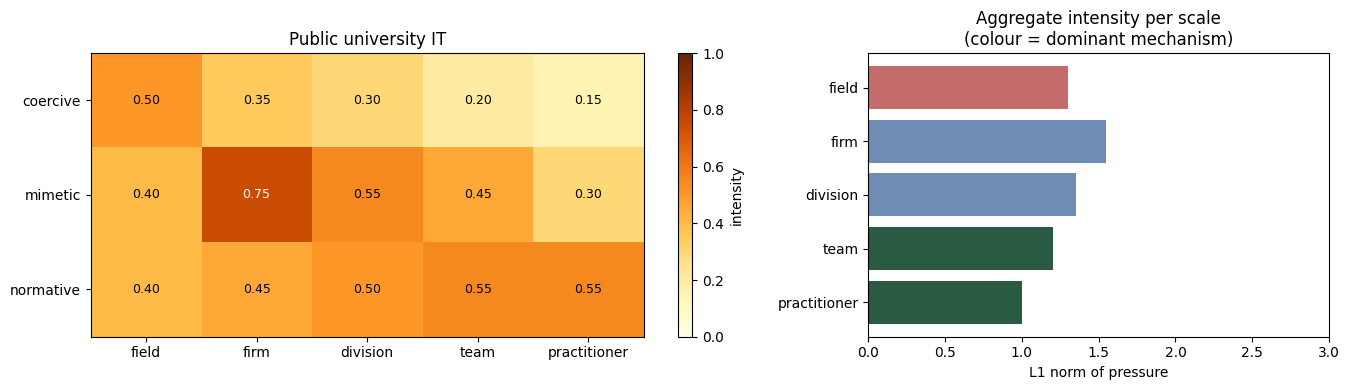


L1 norms by scale (financial-services consulting firm):
          field: L1=1.70 (dominant=coercive)
           firm: L1=1.65 (dominant=mimetic)
       division: L1=1.80 (dominant=mimetic)
           team: L1=1.60 (dominant=normative)
   practitioner: L1=1.40 (dominant=normative)

L1 norms by scale (public university IT):
          field: L1=1.30 (dominant=coercive)
           firm: L1=1.55 (dominant=mimetic)
       division: L1=1.35 (dominant=mimetic)
           team: L1=1.20 (dominant=normative)
   practitioner: L1=1.00 (dominant=normative)


In [4]:
UNIVERSITY_IT = decompose_across_scales(
    'Public university IT: data governance',
    decomposition={
        Scale.FIELD:        {'coercive': 0.50, 'mimetic': 0.40, 'normative': 0.40,
                             'evidence': ['FERPA', 'state data privacy laws']},
        Scale.FIRM:         {'coercive': 0.35, 'mimetic': 0.75, 'normative': 0.45,
                             'evidence': ['EDUCAUSE benchmarking', 'sister-university toolkit imitation']},
        Scale.DIVISION:     {'coercive': 0.30, 'mimetic': 0.55, 'normative': 0.50,
                             'evidence': ['IT department peer practices']},
        Scale.TEAM:         {'coercive': 0.20, 'mimetic': 0.45, 'normative': 0.55,
                             'evidence': ['ITIL conventions']},
        Scale.PRACTITIONER: {'coercive': 0.15, 'mimetic': 0.30, 'normative': 0.55,
                             'evidence': ['individual training; no field-wide certification']},
    },
)
render_pressure_field(UNIVERSITY_IT, title='Public university IT')

print('\nL1 norms by scale (financial-services consulting firm):')
for v in FS_FIRM:
    print(f'  {v.scale.value:>13s}: L1={v.l1():.2f} (dominant={v.dominant()})')
print('\nL1 norms by scale (public university IT):')
for v in UNIVERSITY_IT:
    print(f'  {v.scale.value:>13s}: L1={v.l1():.2f} (dominant={v.dominant()})')


## Where this lands

The `PressureVector` and `Scale` types are reused throughout Chapter 13. The decomposition step is currently human-curated; notebook 13.5 will introduce an AI-mediated path that takes free-text governance accounts and produces decomposition dictionaries automatically (with an explicit mock fallback when no Anthropic key is available).

## Practical implications

- **For practitioners:** a pressure field rendered as a heatmap is more diagnostic than the same intensities listed as text. Build the heatmap before the all-hands deck.
- **For researchers:** when transcribing interviews, retain scale labels. The dissertation's hand-coding already produces this structure; the apparatus operationalizes it.
- **For students:** treat the matrix as one snapshot. Notebook 13.2 introduces a temporal complement: when formal and operational signals diverge across scales, the apparatus says "decoupling" with a number attached.
